In [ ]:
# NEED TO HAVE DATA FILES DOWNLOADED AND UPDATE PATHS

import numpy as np
from pxrr.data_io import (
    load_inputs, metadata_update, save_pseudo_reflectivity, GIXOS_file_output  
)
from pxrr.plots import (
    GIXOS_data_plot_prep, Qxy_GIXOS_data_plot_prep,
    GIXOS_data_plot, R_data_plot, R_pseudo_data_plot,
    GIXOS_vs_Qz_plot, GIXOS_vs_Qxy_plot, dependency_plot, 
    
)
from pxrr.gixos import (binning_GIXOS_data, 
                        remove_negative_2theta, 
                        real_space_2theta,
                        conversion_to_reflectivity,
                        GIXOS_RF_and_SF)
from pxrr.dependency import dependency_real_space_2theta, create_dependency_models
from pxrr.slit import rect_slit_function 
# Optional: if any import above fails due to code refactor, uncomment fallback:
# from pxrr.gixos import *  # fallback (avoid unless needed)

0.040000	0.060000	0.100000	0.150000	0.318000	

/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/pxrr/gixos.py:211: RuntimeWarning: divide by zero encountered in divide
  C_integrand[idx, :] = 2 * pi * r_grid ** (1 - eta_val) * (np.exp(-eta_val * besselk(0, r_grid / Lk)) - 1)
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/pxrr/gixos.py:217: RuntimeWarning: divide by zero encountered in scalar divide
  * np.exp(eta * besselk(0, 1 / (Lk * qmax)))
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/pxrr/gixos.py:98: RuntimeWarning: divide by zero encountered in divide
  term2 = np.exp(-eta[..., None] * besselk(0, rad_term / Lk)) - 1
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/pxrr/gixos.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  exp_term = np.exp(eta * besselk(0, 1 / (Lk * qmax)))
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/pxrr/gixos.py:211: RuntimeWarning: divide by zero encountered in divide
  

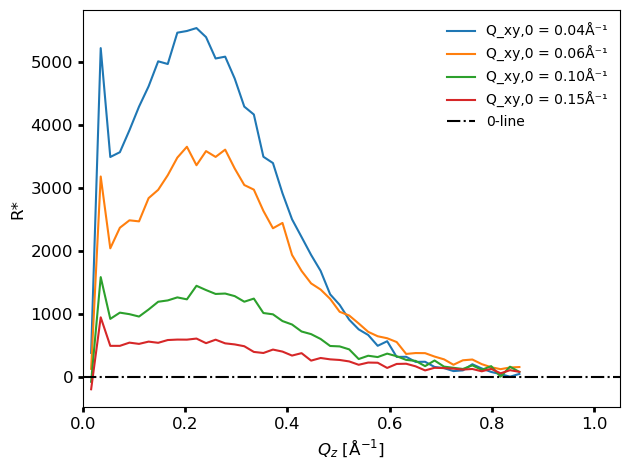

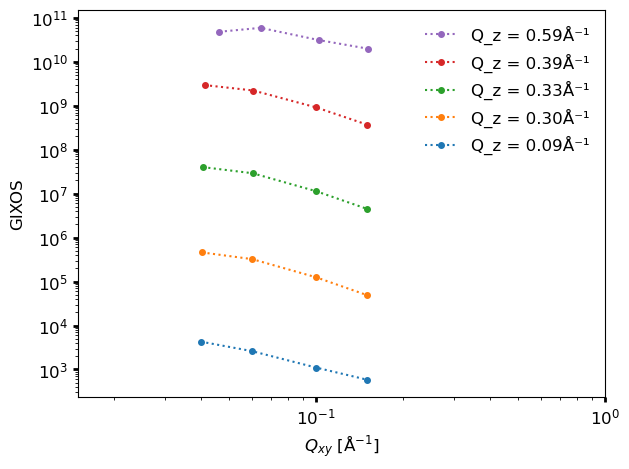

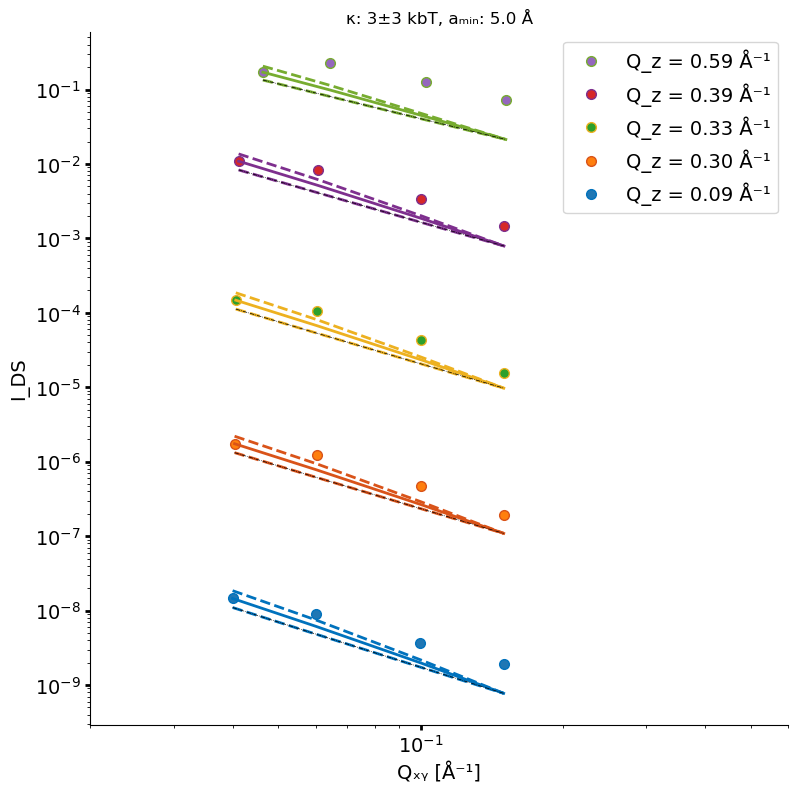

In [2]:
metadata_file = "./testing_data/gixos_metadata.yaml"
importGIXOSdata, importbkg, metadata = load_inputs(metadata_file)
importGIXOSdata, importbkg = binning_GIXOS_data(importGIXOSdata, importbkg)
importGIXOSdata, importbkg, tt_step = remove_negative_2theta(importGIXOSdata, importbkg)
metadata = dependency_real_space_2theta(metadata)
GIXOS, DSbetaHW = Qxy_GIXOS_data_plot_prep(importGIXOSdata, importbkg, metadata, tt_step)
GIXOS_vs_Qz_plot(GIXOS, metadata)
GIXOS_vs_Qxy_plot(GIXOS, metadata)
model, assume_model, CWM_model = create_dependency_models(GIXOS, metadata, DSbetaHW)
dependency_plot(GIXOS, metadata, model, assume_model, CWM_model)

In [4]:
import yaml
from pxrr.data_io import metadata_update
yaml.preserve_quotes = True
sdd = 1039.9
slit_h = 1
# slit_v = 0.66
slit_v = 1
energy = 14400
output_file = './testing_data/gixos_metadata.yaml'
metadata = metadata_update(output_file, locals(), write_yaml=True)

In [5]:
metadata_file = "./testing_data/gixos_metadata.yaml"
importGIXOSdata, importbkg, metadata = load_inputs(metadata_file)
# print(metadata)
importGIXOSdata, importbkg = binning_GIXOS_data(importGIXOSdata, importbkg)
importGIXOSdata, importbkg, tt_step = remove_negative_2theta(importGIXOSdata, importbkg)
metadata = real_space_2theta(metadata)
GIXOS, DSbetaHW = GIXOS_data_plot_prep(importGIXOSdata, importbkg, metadata, tt_step)
GIXOS_data_plot(GIXOS, metadata)
GIXOS = GIXOS_RF_and_SF(GIXOS, metadata, DSbetaHW)
xrr_config = rect_slit_function(GIXOS, metadata)
GIXOS = conversion_to_reflectivity(GIXOS, xrr_config)
# print("xrr_config keys:", xrr_config.keys())
GIXOS_file_output(GIXOS, xrr_config, metadata, tt_step)
R_data_plot(GIXOS, metadata, xrr_config)
R_pseudo_data_plot(GIXOS, metadata, xrr_config)

0.040000	0.060000	0.100000	0.150000	0.318000	

/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/pxrr/slit.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  xrr_data = pd.read_csv(metadata["path_xrr"] + metadata["xrr_datafile"], delim_whitespace=True)


{'energy': 14400, 'sdd': 1039.9, 'slit_h': 1, 'slit_v': 1, 'wavelength': 0.8611111111111112, 'wave_number': 7.296602292208552, 'Qz': array([0.01632588, 0.03505133, 0.05377634, 0.07250059, 0.09122372,
       0.10994533, 0.12866503, 0.14738251, 0.16609733, 0.18480919,
       0.20351767, 0.22222242, 0.24092307, 0.25961927, 0.2783106 ,
       0.29699675, 0.31567734, 0.33435201, 0.35302037, 0.37168206,
       0.39033673, 0.408984  , 0.42762355, 0.44625492, 0.46487786,
       0.48349197, 0.5020969 , 0.52069225, 0.5392777 , 0.55785286,
       0.57641743, 0.59497099, 0.61351325, 0.63204381, 0.65056233,
       0.66906846, 0.68756189, 0.70604221, 0.72450912, 0.74296227,
       0.76140125, 0.77982581, 0.79823557, 0.81663019, 0.83500932,
       0.85337268]), 'dataQz': array([0.01018878, 0.0127361 , 0.01528342, 0.01783073, 0.02037805,
       0.02292537, 0.02547268, 0.02802   , 0.03056731, 0.03311463,
       0.03056731, 0.03566194, 0.04075656, 0.04585118, 0.05094579,
       0.05094579, 0.06113499, 0

/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/.pixi/envs/default/lib/python3.12/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval


{'rf_scalings': [22.942483292886546],
 'offsets': [0.0],
 'file': 'testing_data/output/instrument_46392_RRF_multi_PYTHON.jpg'}

In [6]:
# Examples of multi-curve pseudo reflectivity plotting
# 1. Default single curve (metadata RFscaling)
R_pseudo_data_plot(GIXOS, metadata, xrr_config)

# 2. Multiple scalings without vertical offsets
R_pseudo_data_plot(
    GIXOS, metadata, xrr_config,
    rf_scalings=[metadata['RFscaling'], metadata['RFscaling']*2, metadata['RFscaling']*5]
)

# 3. Multiple scalings with log-scale separation via offsets (10**offset)
R_pseudo_data_plot(
    GIXOS, metadata, xrr_config,
    rf_scalings=[metadata['RFscaling'], metadata['RFscaling']*3],
    offsets=[0, 1]  # second curve lifted by *10^1
)

/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/.pixi/envs/default/lib/python3.12/site-packages/numpy/ma/core.py:3463: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/nsls2/data1/smi/legacy/xf12id1/users/master_notebooks/pxrr_1125/pxrr/.pixi/envs/default/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/nsls2/data1/smi/leg

{'rf_scalings': [22.942483292886546, 68.82744987865964],
 'offsets': [0, 1],
 'file': 'testing_data/output/instrument_46392_RRF_multi_PYTHON.jpg'}

In [7]:
from pxrr.data_io import save_pseudo_reflectivity
path_saved = save_pseudo_reflectivity(GIXOS, metadata)
print(f"Saved pseudo reflectivity (4 cols) to {path_saved}")
print(np.loadtxt(path_saved, skiprows=2)[:5])

Saved pseudo reflectivity (4 cols) to testing_data/output/instrument_pseudo_qx.txt
[[1.632588e-02 1.062613e+01 1.215966e+00 1.053639e-04]
 [3.505133e-02 8.558972e-01 1.600828e-02 3.849057e-04]
 [5.377634e-02 8.406175e-02 2.058642e-03 6.644258e-04]
 [7.250059e-02 2.386132e-02 5.758274e-04 9.439082e-04]
 [9.122372e-02 9.860986e-03 2.205953e-04 1.223337e-03]]
